In [3]:
import pickle

In [4]:
with open(r'E:\satdata\Custom\combined_sst_chlor_cdom_2005-2011.pkl', 'rb') as f:
    data = pickle.load(f)
df = data['data']
metadata = data['metadata']

In [5]:
# Examine the loaded data structure
print("Metadata:")
for key, value in metadata.items():
    print(f"  {key}: {value}")

print("\nDataFrame Info:")
print(df.info())

print("\nDataFrame head:")
print(df.head())

print("\nDataFrame columns:")
print(df.columns.tolist())

print("\nData shape:")
print(f"  Rows: {len(df)}")
print(f"  Columns: {len(df.columns)}")

Metadata:
  lat_centers: [27.5075 27.5225 27.5375 27.5525 27.5675 27.5825 27.5975 27.6125 27.6275
 27.6425 27.6575 27.6725 27.6875 27.7025 27.7175 27.7325 27.7475 27.7625
 27.7775 27.7925 27.8075 27.8225 27.8375 27.8525 27.8675 27.8825 27.8975
 27.9125 27.9275 27.9425 27.9575 27.9725 27.9875 28.0025 28.0175 28.0325
 28.0475 28.0625 28.0775 28.0925 28.1075 28.1225 28.1375 28.1525 28.1675
 28.1825 28.1975 28.2125 28.2275 28.2425 28.2575 28.2725 28.2875 28.3025
 28.3175 28.3325 28.3475 28.3625 28.3775 28.3925 28.4075 28.4225 28.4375
 28.4525 28.4675 28.4825 28.4975 28.5125 28.5275 28.5425 28.5575 28.5725
 28.5875 28.6025 28.6175 28.6325 28.6475 28.6625 28.6775 28.6925 28.7075
 28.7225 28.7375 28.7525 28.7675 28.7825 28.7975 28.8125 28.8275 28.8425
 28.8575 28.8725 28.8875 28.9025 28.9175 28.9325 28.9475 28.9625 28.9775
 28.9925 29.0075 29.0225 29.0375 29.0525 29.0675 29.0825 29.0975 29.1125
 29.1275 29.1425 29.1575 29.1725 29.1875 29.2025 29.2175 29.2325 29.2475
 29.2625 29.2775 29.2925 2

## Visualize Each Product

Now let's create individual plots for each satellite product: SST, Chlorophyll-a, and CDOM.

In [6]:
# Import plotting libraries
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import numpy as np

print("Plotting libraries imported successfully!")

Plotting libraries imported successfully!


In [8]:
# First check what columns we have
print("Available columns in dataframe:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
print(df.head())

Available columns in dataframe:
['sst', 'sst_n_points', 'chlorophyll', 'chlor_n_points', 'cdom', 'cdom_n_points']

First few rows:
                                                          sst  sst_n_points  \
date                                                                          
2005-01-01  [[23.364499999999992, 23.4375, 23.507999999999...      137002.0   
2005-01-02  [[23.28150000000001, 23.310000000000002, 23.32...      137002.0   
2005-01-03  [[23.49825, 23.494749999999996, 23.45825000000...      137002.0   
2005-01-04  [[23.566249999999997, 23.545999999999992, 23.4...      137002.0   
2005-01-05  [[23.455, 23.440000000000012, 23.4502499999999...      137002.0   

           chlorophyll  chlor_n_points cdom  cdom_n_points  
date                                                        
2005-01-01         NaN             NaN  NaN            NaN  
2005-01-02         NaN             NaN  NaN            NaN  
2005-01-03         NaN             NaN  NaN            NaN  
2005-01-04

In [11]:
# Check metadata keys
print("\nMetadata keys:")
print(list(metadata.keys()))


Metadata keys:
['lat_centers', 'lon_centers', 'lat_edges', 'lon_edges', 'bbox', 'grid_shape']


In [12]:
# Helper function to extract and average the 2D arrays across all dates
def extract_temporal_mean(df, column_name):
    """Extract 2D arrays from column and compute temporal mean."""
    arrays = []
    
    for date_idx, row in df.iterrows():
        data = row[column_name]
        if data is not None and not (isinstance(data, float) and np.isnan(data)):
            # Convert to numpy array if not already
            data_array = np.array(data)
            arrays.append(data_array)
    
    if len(arrays) > 0:
        # Stack arrays and compute mean along time axis
        stacked = np.stack(arrays, axis=0)
        temporal_mean = np.nanmean(stacked, axis=0)
        return temporal_mean
    else:
        return None

# Get grid information from metadata
lat_edges = metadata['lat_edges']
lon_edges = metadata['lon_edges']
bbox = metadata['bbox']
grid_shape = metadata['grid_shape']

lon_min, lon_max, lat_min, lat_max = bbox
lat_bins, lon_bins = grid_shape

# Extract temporal means for each product
print("Computing temporal means for each product...")
sst_grid = extract_temporal_mean(df, 'sst')
chlor_grid = extract_temporal_mean(df, 'chlorophyll')
cdom_grid = extract_temporal_mean(df, 'cdom')

print(f"\n2D grids created:")
if sst_grid is not None:
    print(f"  SST: {sst_grid.shape}, valid pixels: {np.sum(~np.isnan(sst_grid))}")
else:
    print(f"  SST: None")
    
if chlor_grid is not None:
    print(f"  Chlorophyll: {chlor_grid.shape}, valid pixels: {np.sum(~np.isnan(chlor_grid))}")
else:
    print(f"  Chlorophyll: None")
    
if cdom_grid is not None:
    print(f"  CDOM: {cdom_grid.shape}, valid pixels: {np.sum(~np.isnan(cdom_grid))}")
else:
    print(f"  CDOM: None")

print(f"\nGrid dimensions: {lat_bins} x {lon_bins}")
print(f"Region: [{lon_min}, {lat_min}] to [{lon_max}, {lat_max}]")

Computing temporal means for each product...


C:\Users\Makai\AppData\Local\Temp\ipykernel_20808\3935241544.py:16: RuntimeWarning: Mean of empty slice
  temporal_mean = np.nanmean(stacked, axis=0)



2D grids created:
  SST: (200, 300), valid pixels: 45949
  Chlorophyll: (200, 300), valid pixels: 47121
  CDOM: (200, 300), valid pixels: 47124

Grid dimensions: 200 x 300
Region: [-94.0, 27.5] to [-88.0, 30.5]


### Sea Surface Temperature (SST)

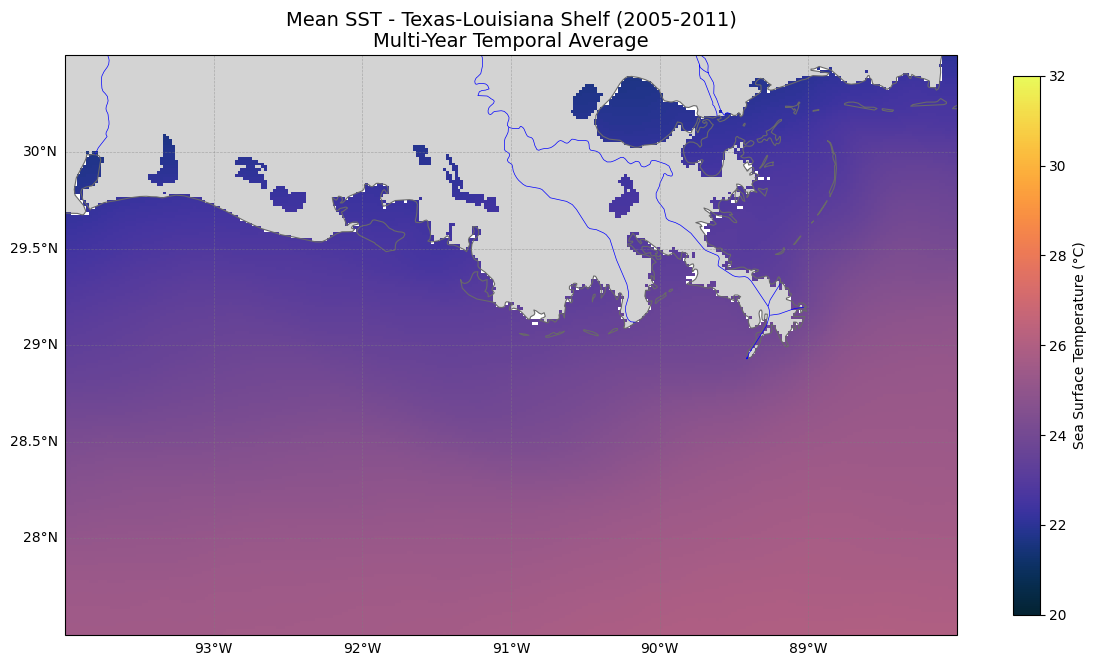


SST Statistics:
  Valid data points: 45949
  Mean SST: 24.33 °C
  Min SST: 21.63 °C
  Max SST: 26.02 °C
  Std Dev: 1.12 °C


In [13]:
# Plot SST
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.set_aspect(1.3, adjustable='box', anchor='C')

# Define SST color range
sst_vmin, sst_vmax = 20, 32

# Plot SST
sst_mesh = ax.pcolormesh(
    lon_edges, lat_edges, sst_grid,
    cmap=cmocean.cm.thermal, shading='auto',
    vmin=sst_vmin, vmax=sst_vmax,
    transform=ccrs.PlateCarree()
)

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='dimGray')
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='dimGray')
ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue')

# Add gridlines
gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True,
    linewidth=0.5, color='gray', alpha=0.5, linestyle='--'
)
gl.top_labels = False
gl.right_labels = False

# Colorbar and title
plt.colorbar(sst_mesh, label='Sea Surface Temperature (°C)', shrink=0.7)
plt.title(f'Mean SST - Texas-Louisiana Shelf (2005-2011)\n' + 
          f'Multi-Year Temporal Average', fontsize=14)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nSST Statistics:")
print(f"  Valid data points: {np.sum(~np.isnan(sst_grid))}")
print(f"  Mean SST: {np.nanmean(sst_grid):.2f} °C")
print(f"  Min SST: {np.nanmin(sst_grid):.2f} °C")
print(f"  Max SST: {np.nanmax(sst_grid):.2f} °C")
print(f"  Std Dev: {np.nanstd(sst_grid):.2f} °C")

### Chlorophyll-a Concentration

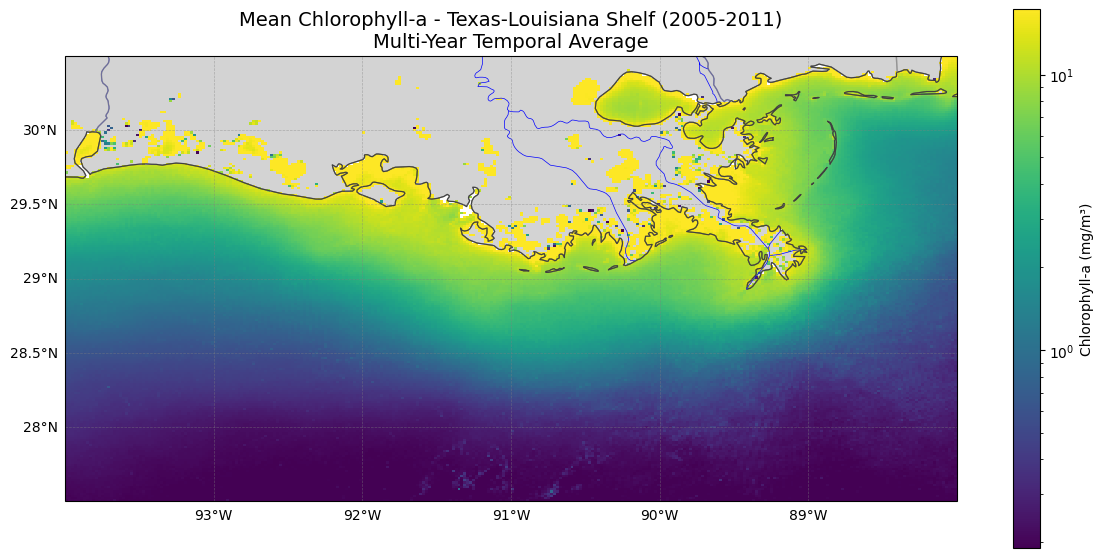


Chlorophyll-a Statistics:
  Valid data points: 47121
  Mean: 4.1406 mg/m³
  Median: 1.2285 mg/m³
  Min: 0.0327 mg/m³
  Max: 83.8374 mg/m³
  Std Dev: 6.5438 mg/m³


In [14]:
# Plot Chlorophyll-a
import matplotlib.colors as colors

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Get valid chlorophyll data for color scaling
valid_chlor = chlor_grid[~np.isnan(chlor_grid)]
if len(valid_chlor) > 0:
    vmin = np.percentile(valid_chlor, 5)
    vmax = np.percentile(valid_chlor, 95)
    if vmin <= 0:
        vmin = 0.01
    if vmax <= vmin:
        vmax = vmin * 10
else:
    vmin, vmax = 0.01, 10

# Plot Chlorophyll with log scale
chlor_mesh = ax.pcolormesh(
    lon_edges, lat_edges, chlor_grid,
    cmap='viridis', shading='auto',
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    transform=ccrs.PlateCarree()
)

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue')
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)

# Add gridlines
gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True,
    linewidth=0.5, color='gray', alpha=0.5, linestyle='--'
)
gl.top_labels = False
gl.right_labels = False

# Colorbar and title
plt.colorbar(chlor_mesh, label='Chlorophyll-a (mg/m³)', shrink=0.7)
plt.title(f'Mean Chlorophyll-a - Texas-Louisiana Shelf (2005-2011)\n' + 
          f'Multi-Year Temporal Average', fontsize=14)

plt.tight_layout()
plt.show()

# Print statistics
if len(valid_chlor) > 0:
    print(f"\nChlorophyll-a Statistics:")
    print(f"  Valid data points: {len(valid_chlor)}")
    print(f"  Mean: {np.mean(valid_chlor):.4f} mg/m³")
    print(f"  Median: {np.median(valid_chlor):.4f} mg/m³")
    print(f"  Min: {np.min(valid_chlor):.4f} mg/m³")
    print(f"  Max: {np.max(valid_chlor):.4f} mg/m³")
    print(f"  Std Dev: {np.std(valid_chlor):.4f} mg/m³")
else:
    print("\nNo valid chlorophyll data to display statistics.")

### CDOM (Colored Dissolved Organic Matter)

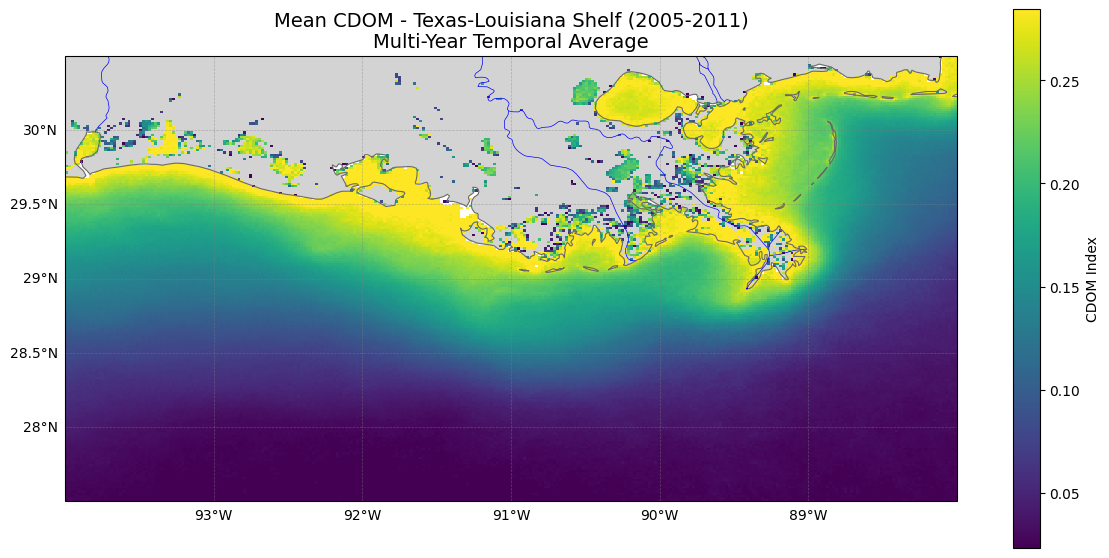


CDOM Statistics:
  Valid data points: 47124
  Mean: 0.122202
  Median: 0.098432
  Min: 0.000208
  Max: 0.832577
  Std Dev: 0.091059


In [15]:
# Plot CDOM
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Get valid CDOM data for color scaling
valid_cdom = cdom_grid[~np.isnan(cdom_grid)]
if len(valid_cdom) > 0:
    vmin = np.percentile(valid_cdom, 5)
    vmax = np.percentile(valid_cdom, 95)
    if vmin >= vmax:
        vmin = np.nanmin(valid_cdom)
        vmax = np.nanmax(valid_cdom)
    if vmin == vmax:
        vmin -= 0.01
        vmax += 0.01
else:
    vmin, vmax = 0, 0.1

# Plot CDOM
cdom_mesh = ax.pcolormesh(
    lon_edges, lat_edges, cdom_grid,
    cmap='viridis', shading='auto',
    vmin=vmin, vmax=vmax,
    transform=ccrs.PlateCarree()
)

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='dimGray')
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='dimGray')
ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue')

# Add gridlines
gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True,
    linewidth=0.5, color='gray', alpha=0.5, linestyle='--'
)
gl.top_labels = False
gl.right_labels = False

# Colorbar and title
plt.colorbar(cdom_mesh, label='CDOM Index', shrink=0.7)
plt.title(f'Mean CDOM - Texas-Louisiana Shelf (2005-2011)\n' + 
          f'Multi-Year Temporal Average', fontsize=14)

plt.tight_layout()
plt.show()

# Print statistics
if len(valid_cdom) > 0:
    print(f"\nCDOM Statistics:")
    print(f"  Valid data points: {len(valid_cdom)}")
    print(f"  Mean: {np.mean(valid_cdom):.6f}")
    print(f"  Median: {np.median(valid_cdom):.6f}")
    print(f"  Min: {np.min(valid_cdom):.6f}")
    print(f"  Max: {np.max(valid_cdom):.6f}")
    print(f"  Std Dev: {np.std(valid_cdom):.6f}")
else:
    print("\nNo valid CDOM data to display statistics.")